In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

from pyspark.ml.feature import (
    StandardScaler,
    MinMaxScaler,
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

from sklearn.utils.class_weight import compute_class_weight

In [2]:
spark = SparkSession.builder \
    .appName("HotelBookings") \
    .getOrCreate()

In [3]:
# Read the CSV file
data = spark.read.csv(
    '/content/hotelbookings.csv',
    header=True,
    inferSchema=True,
    nullValue='NULL'
)

In [4]:
print("Rows:", data.count())
print("Columns:", len(data.columns))

Rows: 66448
Columns: 32


In [5]:
print(data.columns)

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [6]:
data.printSchema()

root
 |-- hotel: string (nullable = true)
 |-- is_canceled: integer (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- arrival_date_year: integer (nullable = true)
 |-- arrival_date_month: string (nullable = true)
 |-- arrival_date_week_number: integer (nullable = true)
 |-- arrival_date_day_of_month: integer (nullable = true)
 |-- stays_in_weekend_nights: integer (nullable = true)
 |-- stays_in_week_nights: integer (nullable = true)
 |-- adults: integer (nullable = true)
 |-- children: double (nullable = true)
 |-- babies: integer (nullable = true)
 |-- meal: string (nullable = true)
 |-- country: string (nullable = true)
 |-- market_segment: string (nullable = true)
 |-- distribution_channel: string (nullable = true)
 |-- is_repeated_guest: integer (nullable = true)
 |-- previous_cancellations: integer (nullable = true)
 |-- previous_bookings_not_canceled: integer (nullable = true)
 |-- reserved_room_type: string (nullable = true)
 |-- assigned_room_type: string (nullab

In [7]:
print(data.count() - data.dropDuplicates().count())

17992


In [8]:
data = data.dropDuplicates()

In [9]:
print(data.count() - data.dropDuplicates().count())

0


In [10]:
null_counts = data.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in data.columns
])

row = null_counts.first()

for c in data.columns:
    if row[c] > 0:
        print(c, ":", row[c])

children : 4
country : 450
agent : 7429
company : 45679
reservation_status_date : 1


In [11]:
total = data.count()

data.groupBy("is_canceled") \
    .count() \
    .withColumn("proportion", col("count") / total) \
    .show()

+-----------+-----+------------------+
|is_canceled|count|        proportion|
+-----------+-----+------------------+
|          1|18749|0.3869283473666832|
|          0|29707|0.6130716526333169|
+-----------+-----+------------------+



In [12]:
data.select("children").distinct().show()
#########################################
data.select("country").distinct().show()

+--------+
|children|
+--------+
|     0.0|
|     1.0|
|    NULL|
|     3.0|
|     2.0|
|    10.0|
+--------+

+-------+
|country|
+-------+
|    POL|
|    LVA|
|    ZMB|
|    JAM|
|    BRA|
|    ARM|
|    MOZ|
|    CUB|
|    JOR|
|    FRA|
|    URY|
|    GIB|
|    ETH|
|     CN|
|    ITA|
|    UKR|
|    CMR|
|    SEN|
|    COM|
|    HRV|
+-------+
only showing top 20 rows


In [13]:
data.select(min("agent")).show()

+----------+
|min(agent)|
+----------+
|       1.0|
+----------+



In [14]:
# company: High percentage of missing values, so drop the column
data = data.drop("company")


# agent: NULL means no agent was used, so fill with 0
data = data.fillna({"agent": 0})


# children: Fill missing values with the mode
children_mode = data.groupBy("children") \
    .count() \
    .orderBy(desc("count")) \
    .first()["children"]

data = data.fillna({"children": children_mode})


# country: Fill missing values with the mode
country_mode = data.groupBy("country") \
    .count() \
    .orderBy(desc("count")) \
    .first()["country"]

data = data.fillna({"country": country_mode})

In [15]:
# Check for remaining NULL values
null_counts = data.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in data.columns
])

row = null_counts.first()

for c in data.columns:
    if row[c] > 0:
        print(c, ":", row[c])

reservation_status_date : 1


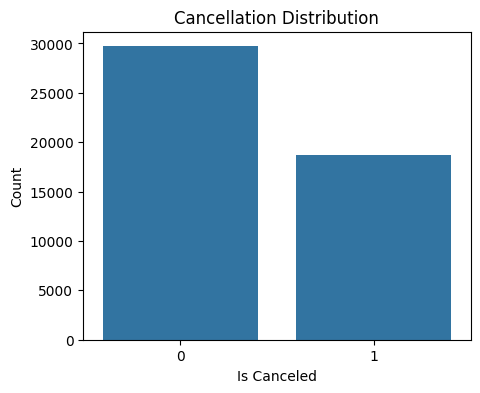

In [16]:
# Count the number of bookings for each cancellation status
cancellation_counts = data.groupBy("is_canceled") \
    .count() \
    .orderBy("is_canceled")

# Convert the result to Pandas for visualization
cancellation_counts_pd = cancellation_counts.toPandas()

# Plot the cancellation distribution
plt.figure(figsize=(5, 4))

sns.barplot(
    x="is_canceled",
    y="count",
    data=cancellation_counts_pd
)

plt.title("Cancellation Distribution")
plt.xlabel("Is Canceled")
plt.ylabel("Count")

plt.show()

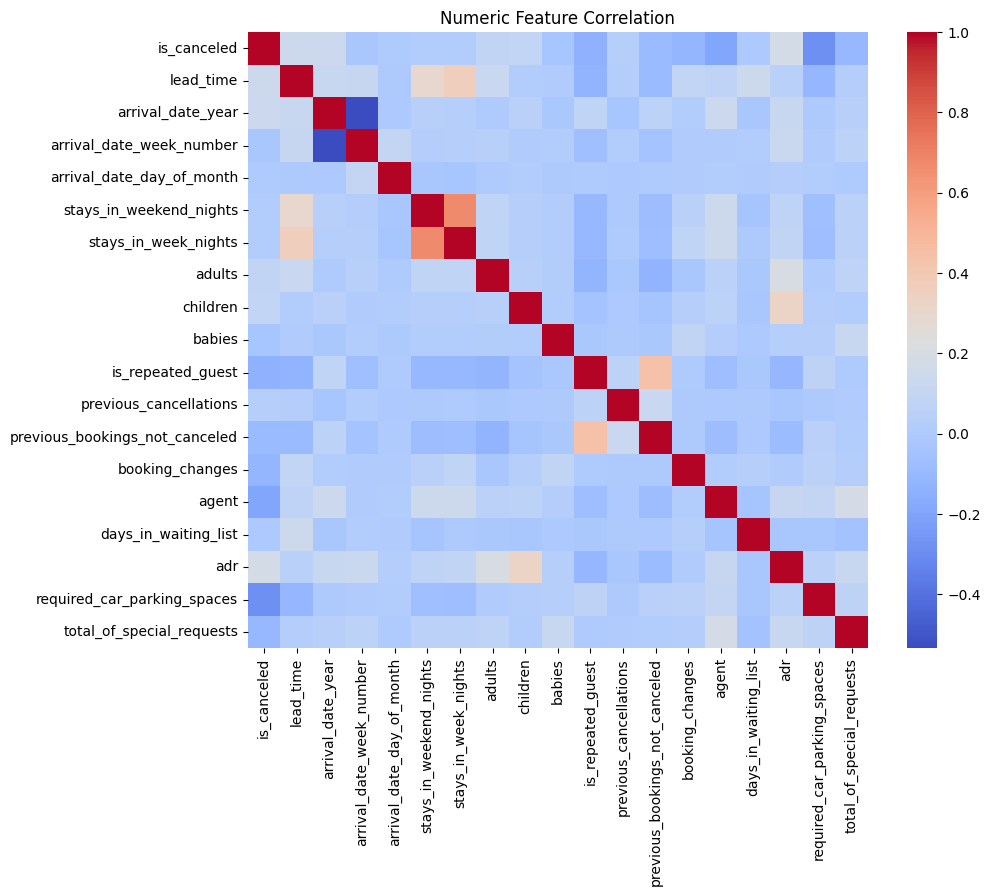

In [17]:
# Get numeric columns
num_cols = [
    field.name
    for field in data.schema.fields
    if field.dataType.simpleString() in ["int", "double", "float", "long"]
]

# Calculate the correlation matrix
corr_matrix = []

for col1 in num_cols:
    row = []
    for col2 in num_cols:
        correlation = data.stat.corr(col1, col2)
        row.append(correlation)
    corr_matrix.append(row)

# Convert the correlation matrix to Pandas
corr_pd = pd.DataFrame(
    corr_matrix,
    index=num_cols,
    columns=num_cols
)

# Plot the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_pd,
    cmap="coolwarm",
    annot=False
)

plt.title("Numeric Feature Correlation")

plt.show()

In [18]:
# Remove rows with 0 total guests
data = data.filter(
    (col("adults") + col("children") + col("babies")) > 0
)

In [19]:
data.filter(col("adr") < 0).show()

+------------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+--------------------+---------------+-----+---------------------------+-------------------------+------------------+-----------------------+
|       hotel|is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|days_in_waiting_list|  customer_type|  adr|required_car_parking_spaces|total_of_special

In [20]:
# Keep rows with non-negative ADR
data = data.filter(col("adr") >= 0)

In [21]:
# Calculate total number of nights
data = data.withColumn(
    "total_nights",
    col("stays_in_weekend_nights") + col("stays_in_week_nights")
)

In [22]:
# Calculate total number of guests
data = data.withColumn(
    "total_guests",
    col("adults") + col("children") + col("babies")
)

In [23]:
# Create a family indicator
data = data.withColumn(
    "is_family",
    when(
        (col("children") > 0) | (col("babies") > 0),
        1
    ).otherwise(0)
)

In [24]:
# Create a room change indicator
data = data.withColumn(
    "room_changed",
    when(
        col("reserved_room_type") != col("assigned_room_type"),
        1
    ).otherwise(0)
)

In [25]:
# Calculate total number of previous bookings
data = data.withColumn(
    "total_previous_bookings",
    col("previous_cancellations") + col("previous_bookings_not_canceled")
)

In [26]:
# Calculate the previous cancellation ratio
data = data.withColumn(
    "prev_cancel_ratio",
    col("previous_cancellations") /
    when(
        col("total_previous_bookings") == 0,
        1
    ).otherwise(col("total_previous_bookings"))
)

In [27]:
# Create a long lead time indicator
data = data.withColumn(
    "long_lead_time",
    when(col("lead_time") > 90, 1).otherwise(0)
)

In [28]:
# Drop columns that are not useful for prediction
data = data.drop(
    "reservation_status",
    "reservation_status_date",
    "arrival_date_day_of_month"
)

In [29]:
# Split the data into training and testing sets

train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training rows:", train_data.count())
print("Testing rows:", test_data.count())

Training rows: 38851
Testing rows: 9569


In [30]:
# Numeric features
numeric_cols = [
    field.name
    for field in train_data.schema.fields
    if field.dataType.simpleString() in ["int", "double", "float", "long"]
]

# Remove target
numeric_features = [
    c for c in numeric_cols
    if c != "is_canceled"
]

# Categorical features
categorical_features = [
    field.name
    for field in train_data.schema.fields
    if field.dataType.simpleString() == "string"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'is_family', 'room_changed', 'total_previous_bookings', 'prev_cancel_ratio', 'long_lead_time']
Categorical features: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [31]:
# One-Hot Encoding

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_index",
        handleInvalid="keep"
    )
    for c in categorical_features
]

encoder = OneHotEncoder(
    inputCols=[c + "_index" for c in categorical_features],
    outputCols=[c + "_encoded" for c in categorical_features]
)

pipeline = Pipeline(
    stages=indexers + [encoder]
)

pipeline_model = pipeline.fit(train_data)

train_encoded = pipeline_model.transform(train_data)
test_encoded = pipeline_model.transform(test_data)

In [32]:
encoded_categorical_features = [
    c + "_encoded"
    for c in categorical_features
]

feature_cols = numeric_features + encoded_categorical_features

print("Number of features:", len(feature_cols))
print("Features:", feature_cols)

Number of features: 34
Features: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'is_family', 'room_changed', 'total_previous_bookings', 'prev_cancel_ratio', 'long_lead_time', 'hotel_encoded', 'arrival_date_month_encoded', 'meal_encoded', 'country_encoded', 'market_segment_encoded', 'distribution_channel_encoded', 'reserved_room_type_encoded', 'assigned_room_type_encoded', 'deposit_type_encoded', 'customer_type_encoded']


In [33]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_assembled = assembler.transform(train_encoded)
test_assembled = assembler.transform(test_encoded)

In [34]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(train_assembled)

train_scaled = scaler_model.transform(train_assembled)

test_scaled = scaler_model.transform(test_assembled)

In [35]:
import numpy as np

# Convert training scaled features to Pandas (from spark dataframe to pandas dataframe)
train_pd = train_scaled.select(
    "scaled_features",
    "is_canceled"
).toPandas()

# Convert Spark vectors to NumPy array
X_train_scaled = np.vstack(
    train_pd["scaled_features"]
    .apply(lambda x: x.toArray())
    .values
)

# Convert target to NumPy array
y_train = train_pd["is_canceled"].to_numpy()

print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

X_train shape: (38851, 223)
y_train shape: (38851,)


In [36]:
# Convert test scaled features to Pandas
test_pd = test_scaled.select(
    "scaled_features",
    "is_canceled"
).toPandas()

# Convert Spark vectors to NumPy array
X_test_scaled = np.vstack(
    test_pd["scaled_features"]
    .apply(lambda x: x.toArray())
    .values
)

# Convert target to NumPy array
y_test = test_pd["is_canceled"].to_numpy()

print("X_test shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)

X_test shape: (9569, 223)
y_test shape: (9569,)


In [37]:
from sklearn.model_selection import train_test_split

# The rows in X_train_scaled/y_train come from Spark's toPandas() and are NOT
# randomly ordered (they follow partition order), so Keras' validation_split
# (which just slices off the last 20% of the array) does not give a
# representative validation set. Build an explicit, shuffled, stratified
# validation split instead.
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("X_train_final shape:", X_train_final.shape)
print("X_val shape:", X_val.shape)


X_train_final shape: (31080, 223)
X_val shape: (7771, 223)


In [38]:
# Count samples in each class
class_counts = (
    train_data
    .groupBy("is_canceled")
    .count()
    .collect()
)

# Total number of training samples
total_samples = train_data.count()

# Number of classes (2)
num_classes = len(class_counts)

# Calculate balanced class weights
class_weight_dict = {}

for row in class_counts:
    class_label = int(row["is_canceled"])
    class_count = row["count"]

    class_weight_dict[class_label] = (
        total_samples / (num_classes * class_count)
    )

print("Class weights:", class_weight_dict)

Class weights: {1: 1.2933089214380826, 0: 0.8151357475557047}


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

# Number of input features
input_dim = X_train_final.shape[1]

# Build the neural network
model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [42]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/100
486/486 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7841 - auc: 0.8672 - loss: 0.4598 - val_accuracy: 0.8443 - val_auc: 0.9272 - val_loss: 0.3467
Epoch 2/100
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8349 - auc: 0.9209 - loss: 0.3561 - val_accuracy: 0.8502 - val_auc: 0.9365 - val_loss: 0.3184
Epoch 3/100
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8442 - auc: 0.9315 - loss: 0.3313 - val_accuracy: 0.8592 - val_auc: 0.9434 - val_loss: 0.3038
Epoch 4/100
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8497 - auc: 0.9378 - loss: 0.3152 - val_accuracy: 0.8583 - val_auc: 0.9469 - val_loss: 0.2943
Epoch 5/100
486/486 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8586 - auc: 0.9437 - loss: 0.2998 - val_accuracy: 0.8678 - val_auc: 0.9511 - val_loss: 0.2841
Epoch 6/100
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8642 - auc: 0.9470 - loss: 0.2911 - val_accuracy: 0.8699 - val_auc: 0.9515 - val_loss: 0.2848
Epoch 7/100
486/486 ━━━━━━━━━━━━━━

In [43]:
# prediction

y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [44]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("\nClassification Report (default threshold=0.5):\n", classification_report(y_test, y_pred))


Accuracy: 0.8804472776674679
ROC-AUC: 0.957528437536721

Classification Report (default threshold=0.5):
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      5852
           1       0.83      0.87      0.85      3717

    accuracy                           0.88      9569
   macro avg       0.87      0.88      0.88      9569
weighted avg       0.88      0.88      0.88      9569



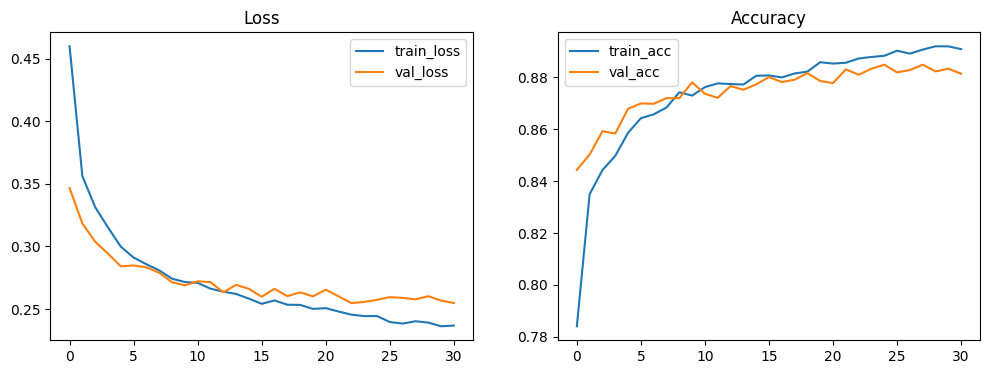

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train_acc')
axes[1].plot(history.history['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.show()

In [46]:
from pyspark.sql.functions import avg

summary = f"""
Hotel Booking Dataset Analysis:

Number of bookings: {data.count()}

Number of columns: {len(data.columns)}

Cancellation rate:
{data.agg(avg("is_canceled")).collect()[0][0] * 100:.2f}%

Average lead time:
{data.agg(avg("lead_time")).collect()[0][0]:.2f} days

Average daily rate:
{data.agg(avg("adr")).collect()[0][0]:.2f}

Average weekend nights:
{data.agg(avg("stays_in_weekend_nights")).collect()[0][0]:.2f}

Average weekday nights:
{data.agg(avg("stays_in_week_nights")).collect()[0][0]:.2f}
"""

print(summary)


Hotel Booking Dataset Analysis:

Number of bookings: 48420

Number of columns: 35

Cancellation rate:
38.70%

Average lead time:
83.00 days

Average daily rate:
100.84

Average weekend nights:
1.13

Average weekday nights:
2.98



In [50]:
# GenAI Analysis

prompt = f"""
You are a hotel booking data analyst.

Analyze the following hotel booking dataset summary:

{summary}

Give me:
1. 5 important insights
2. 5 unusual findings
3. 10 business recommendations

Keep the answer simple and clear.
"""

print(prompt)


You are a hotel booking data analyst.

Analyze the following hotel booking dataset summary:


Hotel Booking Dataset Analysis:

Number of bookings: 48420

Number of columns: 35

Cancellation rate:
38.70%

Average lead time:
83.00 days

Average daily rate:
100.84

Average weekend nights:
1.13

Average weekday nights:
2.98


Give me:
1. 5 important insights
2. 5 unusual findings
3. 10 business recommendations

Keep the answer simple and clear.



In [51]:
!pip install -q openai

In [52]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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"
)

response = client.chat.completions.create(
    model="openrouter/free",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

print(response.choices[0].message.content)

## 1. 5 Important Insights

1. **High booking volume**  
   The dataset has **48,420 bookings**, which is large enough for useful business analysis.

2. **Cancellation rate is high**  
   About **38.7%** of bookings are cancelled, meaning nearly **4 out of 10 bookings do not result in a stay**.

3. **Customers book well in advance**  
   The average lead time is **83 days**, so most guests plan trips quite early.

4. **Weekday stays are longer than weekend stays**  
   Guests stay an average of **2.98 weekday nights**, compared with **1.13 weekend nights**.

5. **Average daily rate is moderate**  
   The average daily rate is **100.84**, which can help estimate revenue potential.

---

## 2. 5 Unusual Findings

1. **Cancellation rate may be a major revenue risk**  
   A 38.7% cancellation rate is high and could significantly reduce occupied rooms.

2. **Weekday nights are much higher than weekend nights**  
   Guests stay about **2.6 times longer on weekdays** than on weekends.

3. **W